In [1]:
import yaml
import numpy as np
from dotmap import DotMap
import matplotlib.pyplot as plt

#### Load the evaluation configuration

In [2]:
config_file = "runs_debug/UVFDDPG/CenterDot/job_530956.centerdot/2024-07-30-16-52-28/lag/2024-07-30-21-31-48/bk/bk_config.yaml"
with open(config_file, 'r') as f:
    config = yaml.safe_load(f)
config = DotMap(config)
trained_cost_limit = config.agent.cost_limit

#### Extract the metrics from records

In [3]:
def extract_metrics(records):
    success_rate = 0.0
    steps = []
    rewards = []
    cumulative_costs = []
    for record in records:
        if record["cumulative_costs"] < trained_cost_limit:
            if record["success"]:
                success_rate += 1
        steps.append(record["steps"])
        rewards.append(record["rewards"])
        cumulative_costs.append(record["cumulative_costs"])

    metrics = {
        'steps': steps,
        'rewards': rewards,
        'cumulative_costs': cumulative_costs, 
        'success_rate': success_rate / len(records),
    }
    return metrics

## Single-Agent Comparisons

In [4]:
unconstrained_records = np.load("pud/plots/data/unconstrained_records.npy", allow_pickle=True)
unconstrained_search_records = np.load("pud/plots/data/unconstrained_search_records.npy", allow_pickle=True)
constrained_records = np.load("pud/plots/data/constrained_records.npy", allow_pickle=True)
constrained_search_factored_records = np.load("pud/plots/data/constrained_search_factored_records.npy", allow_pickle=True)

unconstrained_metrics = extract_metrics(unconstrained_records)
unconstrained_search_metrics = extract_metrics(unconstrained_search_records)
constrained_metrics = extract_metrics(constrained_records)
constrained_search_factored_metrics = [extract_metrics(csr) for csr in constrained_search_factored_records]

In [5]:
def plot_success_rate(metrics):
    unconstrained_sr = metrics[0]['success_rate']
    unconstrained_search_sr = metrics[1]['success_rate']
    constrained_sr = metrics[2]['success_rate']
    constrained_search_srates = [metric["success_rate"] for metric in metrics[3]]

    _, ax = plt.subplots(figsize=(7, 5))

    ax.bar(
        ['Unconstrained', 'Unconstrained\nSearch', 'Constrained', 'Constrained\nSearch (0.1)', 'Constrained\nSearch (0.5)', 'Constrained\nSearch (1.0)'],
        [unconstrained_sr, unconstrained_search_sr, constrained_sr, *constrained_search_srates],
        color=['pink', 'lightblue', 'lightgreen', 'orange', '#e6e6fa', '#ffdab9'],
    )
    ax.set_ylim(0, 1)
    ax.set_xlabel('Method')
    ax.set_title(f'Success Rate (Cost Limit = {trained_cost_limit})')
    ax.set_ylabel('Success Rate')

    plt.tight_layout()
    plt.show()

In [6]:
def plot_bplots(data, labels, plot_params):
    _, ax = plt.subplots(figsize=(7, 5))

    bplot = ax.boxplot(data, vert=True, notch=False, patch_artist=True, showfliers=False)
    colors=['pink', 'lightblue', 'lightgreen', 'orange', 'tomato', 'peachpuff']
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)  # type: ignore

    ax.set_title(plot_params['title'])
    ax.set_ylabel(plot_params['ylabel'])
    ax.set_xlabel(plot_params['xlabel'])
    ax.set_xticklabels(labels)

    plt.tight_layout()
    plt.show()

In [7]:
def plot_steps(metrics):
    unconstrained_steps = metrics[0]['steps']
    unconstrained_search_steps = metrics[1]['steps']
    constrained_steps = metrics[2]['steps']
    constrained_search_steps = [metric["steps"] for metric in metrics[3]]

    plot_bplots(
        [unconstrained_steps, unconstrained_search_steps, constrained_steps, *constrained_search_steps],
        ['Unconstrained', 'Unconstrained\nSearch', 'Constrained', 'Constrained\nSearch (0.1)', 'Constrained\nSearch (0.5)', 'Constrained\nSearch (1.0)'],
        {'title': f'Steps (Cost Limit: {trained_cost_limit})', 'ylabel': 'Steps', 'xlabel': 'Method'}
    )

In [8]:
def plot_rewards(metrics):
    unconstrained_rewards = metrics[0]['rewards']
    unconstrained_search_rewards = metrics[1]['rewards']
    constrained_rewards = metrics[2]['rewards']
    constrained_search_rewards = [metric['rewards'] for metric in metrics[3]]

    plot_bplots(
        [unconstrained_rewards, unconstrained_search_rewards, constrained_rewards, *constrained_search_rewards],
        ['Unconstrained', 'Unconstrained\nSearch', 'Constrained', 'Constrained\nSearch (0.1)', 'Constrained\nSearch (0.5)', 'Constrained\nSearch (1.0)'],
        {'title': f'Rewards (Cost Limit: {trained_cost_limit})', 'ylabel': 'Rewards', 'xlabel': 'Method'}
    )

In [9]:
def plot_cumulative_costs(metrics):
    unconstrained_cc = metrics[0]['cumulative_costs']
    unconstrained_search_cc = metrics[1]['cumulative_costs']
    constrained_cc = metrics[2]['cumulative_costs']
    constrained_search_cc = [metric['cumulative_costs'] for metric in metrics[3]]

    plot_bplots(
        [unconstrained_cc, unconstrained_search_cc, constrained_cc, *constrained_search_cc],
        ['Unconstrained', 'Unconstrained\nSearch', 'Constrained', 'Constrained\nSearch (0.1)', 'Constrained\nSearch (0.5)', 'Constrained\nSearch (1.0)'],
        {'title': f'Cumulative Costs (Cost Limit: {trained_cost_limit})', 'ylabel': 'Cumulative Costs', 'xlabel': 'Method'}
    )

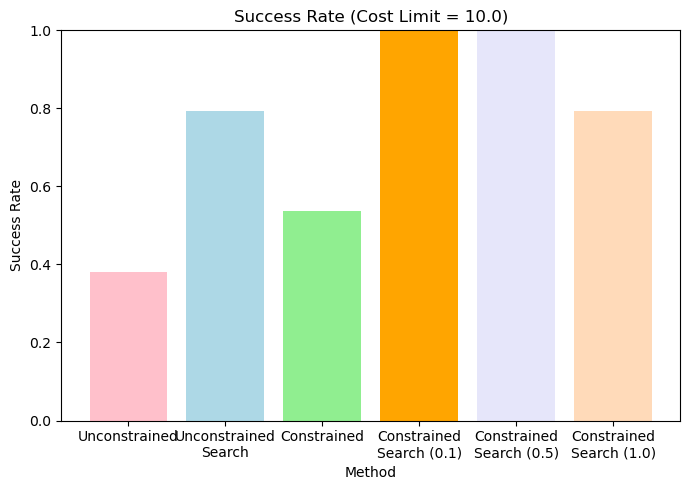

In [10]:
plot_success_rate([unconstrained_metrics, unconstrained_search_metrics, constrained_metrics, constrained_search_factored_metrics])

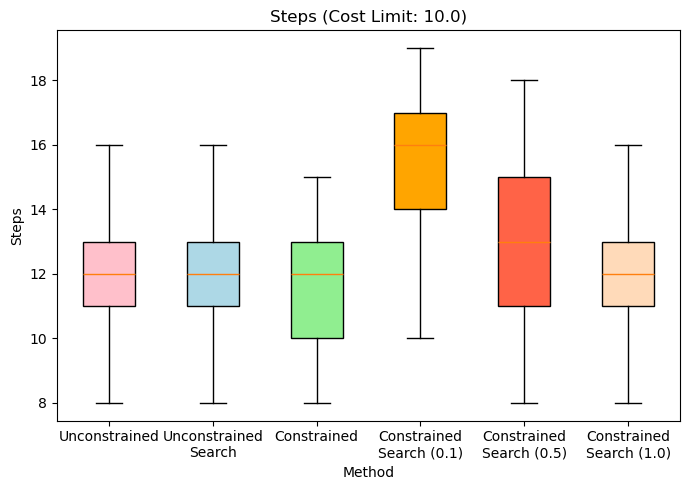

In [11]:
plot_steps([unconstrained_metrics, unconstrained_search_metrics, constrained_metrics, constrained_search_factored_metrics])

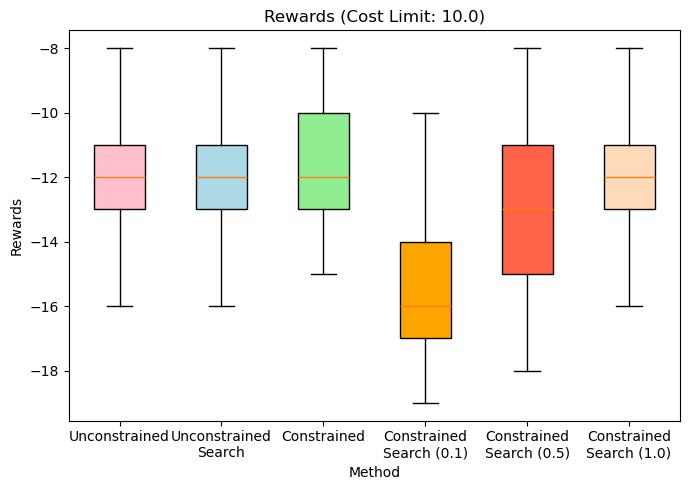

In [12]:
plot_rewards([unconstrained_metrics, unconstrained_search_metrics, constrained_metrics, constrained_search_factored_metrics])

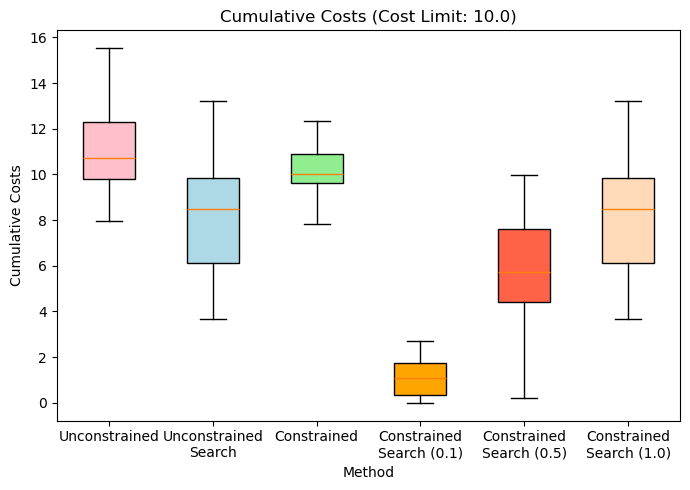

In [13]:
plot_cumulative_costs([unconstrained_metrics, unconstrained_search_metrics, constrained_metrics, constrained_search_factored_metrics])